# 🦜 Colombian Bird Song — Model Training (SageMaker + S3)

Train a ResNet50V2-based species classifier on normalized log-Mel spectrogram tensors fetched from S3.
Runs on AWS SageMaker Notebook Instance with preprocessing artifacts stored in S3.

---

## Pipeline Overview

| Step | Description |
|------|-------------|
| 1 | Setup & install dependencies |
| 1b | Pre-flight AWS validation |
| 2 | Configuration (S3 paths & hyperparameters) |
| 3 | Fetch preprocessing artifacts from S3 |
| 4 | Load dataset index & inspect class distribution |
| 5 | Build `tf.data` pipelines |
| 6 | Build model (ResNet50V2 + classification head) |
| 7 | Phase 1 — train classification head |
| 8 | Phase 2 — fine-tune top layers |
| 9 | Evaluation & diagnostics |
| 10 | Save model locally & upload to S3 |
| 11 | Inference helper (S3-compatible) |

## Step 1 — Setup

Install required packages. Run once per Colab session.

In [1]:
# %pip install tensorflow scikit-learn matplotlib seaborn boto3 --quiet

In [2]:
import importlib.util
import os
import subprocess
import sys

# Avoid reinstalling TensorFlow inside a live managed kernel. Reinstalling core
# runtime packages can destabilize SageMaker/Colab sessions.
REQUIRED_PACKAGES = {
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "boto3": "boto3",
    "pandas": "pandas",
    "pyarrow": "pyarrow",
}
missing_packages = [
    package_name
    for module_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]
if missing_packages:
    print(f"Installing missing packages: {missing_packages}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing_packages])
else:
    print("Required non-TensorFlow packages are already available.")

# This environment flag must be set before TensorFlow initializes GPUs.
os.environ.setdefault("TF_FORCE_GPU_ALLOW_GROWTH", "true")

import tensorflow as tf
import boto3

# Configure TensorFlow before any operation that can initialize the GPU runtime.
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU memory growth enabled for {len(gpus)} GPU(s).")
    except RuntimeError as exc:
        print(f"Could not set GPU memory growth; restart the kernel and run Step 1 first: {exc}")
else:
    print("No GPU detected, running on CPU.")

print(f"TensorFlow : {tf.__version__}")
print(f"GPU devices: {gpus}")
print(f"boto3      : {boto3.__version__}")

Installing missing packages: ['pyarrow']


I0000 00:00:1781097391.194166   11631 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781097391.257143   11631 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781097396.048475   11631 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU memory growth enabled for 1 GPU(s).
TensorFlow : 2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
boto3      : 1.43.25


In [3]:
import boto3
import os

# ── Check boto3 and AWS credentials ──────────────────────────────────────
print("AWS & boto3 Configuration Check")
print("─" * 50)

try:
    # Create S3 client and verify connectivity
    s3_check = boto3.client("s3")
    
    # Try to read SageMaker execution role (if available)
    sts = boto3.client("sts")
    identity = sts.get_caller_identity()
    account_id = identity["Account"]
    arn = identity["Arn"]
    print(f"✓ AWS credentials configured")
    print(f"  Account : {account_id}")
    print(f"  ARN     : {arn}")
    
    # Infer region
    region = os.environ.get("AWS_REGION", "us-east-1")
    print(f"  Region  : {region}")
    
except Exception as e:
    print(f"✗ AWS credential error: {e}")
    print(f"  Ensure SageMaker Notebook Instance has IAM role with S3 access.")
    raise

print("\n✓ Pre-flight check complete. Ready to proceed.")

AWS & boto3 Configuration Check
──────────────────────────────────────────────────
✓ AWS credentials configured
  Account : 760964999831
  ARN     : arn:aws:sts::760964999831:assumed-role/birdsongs-dev-role-sagemaker-gpu-training/SageMaker
  Region  : us-east-1

✓ Pre-flight check complete. Ready to proceed.


## Step 1b — Pre-flight AWS Validation

Verify AWS credentials and permissions before attempting S3 operations.
IAM role must have `s3:GetObject` (for downloads) and `s3:PutObject` (for model uploads).

## Step 2 — Configuration

**Important:** Configure S3 paths in this step before running the notebook.

- `S3_FEATURE_ROOT`: S3 prefix containing the preprocessing artifacts.
- `DATASET_INDEX_KEY`: relative key for `dataset_index.parquet`.
- `NORM_STATS_KEY`: relative key for `norm_stats.parquet`.
- `SPECTROGRAMS_PREFIX`: relative prefix containing normalized `.npy` tensors.
- `S3_OUTPUT_BUCKET`: S3 path where trained models will be saved.

IAM role must have permissions: `s3:GetObject` for input artifacts and `s3:PutObject` for model uploads.

In [17]:
# ── AWS S3 Paths ─────────────────────────────────────────────────────────
# Configure these paths before running. Example:
#   S3_FEATURE_ROOT  = "s3://my-bucket/bird_project/"
#   S3_OUTPUT_BUCKET = "s3://my-bucket/bird-models/"
S3_FEATURE_ROOT  = "s3://birdsongs-dev-sagemaker-training-760964999831/features/"     # ← UPDATE with preprocessing artifact root
S3_OUTPUT_BUCKET = "s3://birdsongs-dev-sagemaker-training-760964999831/outputs/"      # ← UPDATE with actual S3 path

# Relative to S3_FEATURE_ROOT. These match pre_processing.ipynb output paths.
DATASET_INDEX_KEY   = "dataset_index.parquet"
NORM_STATS_KEY      = "norm_stats.parquet"
SPECTROGRAMS_PREFIX = "tensors/"

# ── Data pipeline ─────────────────────────────────────────────────────────
# Conservative defaults for Colab/SageMaker. Increase BATCH_SIZE only after
# confirming the memory report in Step 4 leaves enough RAM/VRAM headroom.
BATCH_SIZE     = 24
SHUFFLE_BUFFER = 10_000

# ── Model ─────────────────────────────────────────────────────────────────
# Defaults are validated and overwritten from a sampled tensor in Step 4.
INPUT_HEIGHT   = 128
INPUT_WIDTH    = 431
INPUT_CHANNELS = 1
DROPOUT_RATE   = 0.3
DENSE_UNITS    = 256

# ── Phase 1: train head only (base frozen) ────────────────────────────────
EPOCHS_PHASE1  = 30
LR_PHASE1      = 1e-3

# ── Phase 2: fine-tune top layers ─────────────────────────────────────────
EPOCHS_PHASE2  = 53
LR_PHASE2      = 1e-4       # 10× lower than phase 1
UNFREEZE_FROM  = -50        # unfreeze the last N layers of the ResNet base

# ── Callbacks ─────────────────────────────────────────────────────────────
EARLY_STOP_PATIENCE    = 6
REDUCE_LR_PATIENCE     = 3
REDUCE_LR_FACTOR       = 0.3

# Name used for local/S3 model artifacts and diagnostic plots.
RUN_NAME = f"index_split_{EPOCHS_PHASE1}-{EPOCHS_PHASE2}"

print("Configuration loaded.")
print(f"  Run         : {RUN_NAME}")
print(f"  Batch       : {BATCH_SIZE}")
print(f"  Shuffle buf : {SHUFFLE_BUFFER}")
print(f"  Input shape : ({INPUT_HEIGHT}, {INPUT_WIDTH}, {INPUT_CHANNELS})")
print(f"  Phase 1     : {EPOCHS_PHASE1} epochs @ lr={LR_PHASE1}")
print(f"  Phase 2     : {EPOCHS_PHASE2} epochs @ lr={LR_PHASE2}  (unfreeze last {abs(UNFREEZE_FROM)} layers)")
print(f"  S3 features : {S3_FEATURE_ROOT}")
print(f"  S3 output   : {S3_OUTPUT_BUCKET}")

Configuration loaded.
  Run         : index_split_30-53
  Batch       : 24
  Shuffle buf : 10000
  Input shape : (128, 431, 1)
  Phase 1     : 30 epochs @ lr=0.001
  Phase 2     : 53 epochs @ lr=0.0001  (unfreeze last 50 layers)
  S3 features : s3://birdsongs-dev-sagemaker-training-760964999831/features/
  S3 output   : s3://birdsongs-dev-sagemaker-training-760964999831/outputs/


## Step 3 — Fetch Preprocessing Artifacts from S3

Download the dataset index and normalization statistics generated by `pre_processing.ipynb`, then configure local cache paths for the normalized `.npy` spectrogram tensors.
Requires SageMaker Notebook Instance IAM role with `s3:GetObject` permission.

In [18]:
import boto3
from pathlib import Path

# ── Initialize S3 client ──────────────────────────────────────────────────
s3_client = boto3.client("s3")

# ── Parse S3 paths ───────────────────────────────────────────────────────
def parse_s3_path(s3_path):
    """Extract bucket and prefix from s3://bucket/prefix/."""
    parts = s3_path.replace("s3://", "").rstrip("/").split("/", 1)
    bucket = parts[0]
    prefix = parts[1] if len(parts) > 1 else ""
    return bucket, prefix


def ensure_trailing_slash(prefix):
    return f"{prefix}/" if prefix and not prefix.endswith("/") else prefix


s3_feature_bucket, s3_feature_prefix = parse_s3_path(S3_FEATURE_ROOT)
s3_output_bucket, s3_output_prefix = parse_s3_path(S3_OUTPUT_BUCKET)
s3_feature_prefix = ensure_trailing_slash(s3_feature_prefix)
s3_output_prefix = ensure_trailing_slash(s3_output_prefix)
SPECTROGRAMS_PREFIX = ensure_trailing_slash(SPECTROGRAMS_PREFIX)

# ── Local storage paths ──────────────────────────────────────────────────
LOCAL_BASE     = Path("/tmp")
LOCAL_FEATURES = LOCAL_BASE / "bird_features"
LOCAL_TENSORS  = LOCAL_FEATURES / "spectrograms"
MODELS_DIR     = LOCAL_BASE / "bird_models"
for directory in (LOCAL_FEATURES, LOCAL_TENSORS, MODELS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

DATASET_INDEX_PATH = LOCAL_FEATURES / "dataset_index.parquet"
NORM_STATS_PATH    = LOCAL_FEATURES / "norm_stats.parquet"
CHECKPOINT_PATH    = MODELS_DIR / f"{RUN_NAME}_best.weights.h5"
FINAL_MODEL_PATH   = MODELS_DIR / f"resnet50v2_{RUN_NAME}.keras"

print(f"Local features dir : {LOCAL_FEATURES}")
print(f"Local tensors dir  : {LOCAL_TENSORS}")
print(f"Models dir         : {MODELS_DIR}")
print(f"S3 feature bucket  : {s3_feature_bucket}")
print(f"S3 feature prefix  : {s3_feature_prefix or '(root)'}")

# ── Helpers ───────────────────────────────────────────────────────────────
def artifact_key(relative_key):
    """Build an S3 key below S3_FEATURE_ROOT."""
    return f"{s3_feature_prefix}{str(relative_key).lstrip('/')}".lstrip("/")


def s3_download_file(bucket, key, local_path):
    """Download a single file from S3 to local storage."""
    local_path = Path(local_path)
    local_path.parent.mkdir(parents=True, exist_ok=True)
    print(f"  Downloading s3://{bucket}/{key} → {local_path}")
    try:
        s3_client.download_file(bucket, key, str(local_path))
        print(f"    ✓ Success ({local_path.stat().st_size / 1_048_576:.1f} MB)")
    except Exception as e:
        print(f"    ✗ Failed: {e}")
        raise


def tensor_s3_key(tensor_path):
    """Map an indexed tensor path to its S3 key under SPECTROGRAMS_PREFIX."""
    filename = Path(str(tensor_path)).name
    return artifact_key(f"{SPECTROGRAMS_PREFIX}{filename}")


def local_tensor_path(tensor_path):
    """Return the local cache path for an indexed tensor."""
    return LOCAL_TENSORS / Path(str(tensor_path)).name

# ── Download small preprocessing artifacts ───────────────────────────────
print("\nDownloading preprocessing artifacts...")
s3_download_file(s3_feature_bucket, artifact_key(DATASET_INDEX_KEY), DATASET_INDEX_PATH)
s3_download_file(s3_feature_bucket, artifact_key(NORM_STATS_KEY), NORM_STATS_PATH)

# ── Verify downloads ────────────────────────────────────────────────────
print("\nVerifying downloaded artifacts...")
for fpath in [DATASET_INDEX_PATH, NORM_STATS_PATH]:
    if not fpath.exists():
        raise FileNotFoundError(f"Missing file: {fpath}")
    size_mb = fpath.stat().st_size / 1_048_576
    print(f"  ✓ {fpath.name:<35} {size_mb:6.1f} MB")

print("\n✓ Preprocessing artifacts downloaded successfully.")
print(f"Tensor cache : {LOCAL_TENSORS}")
print(f"Output will be saved to S3: {S3_OUTPUT_BUCKET}")

Local features dir : /tmp/bird_features
Local tensors dir  : /tmp/bird_features/spectrograms
Models dir         : /tmp/bird_models
S3 feature bucket  : birdsongs-dev-sagemaker-training-760964999831
S3 feature prefix  : features/

    ✓ Success (0.7 MB)
    ✓ Success (0.0 MB)

Verifying downloaded artifacts...
  ✓ dataset_index.parquet                  0.7 MB
  ✓ norm_stats.parquet                     0.0 MB

✓ Preprocessing artifacts downloaded successfully.
Tensor cache : /tmp/bird_features/spectrograms
Output will be saved to S3: s3://birdsongs-dev-sagemaker-training-760964999831/outputs/


## Step 4 — Load Dataset Index & Inspect Class Distribution

Loads `dataset_index.parquet`, filters the preprocessing `train` and `val` splits, caches the referenced normalized tensors locally, and prints tensor shape, dtype, and class distribution summaries.

Rows in index : 60,570
Classes       : 117
Train rows    : 48,570
Val rows      : 6,000


Caching train tensors: 100%|██████████| 48570/48570 [00:01<00:00, 43959.58tensor/s]


train tensors cached: downloaded=0, reused=48,570


Caching val tensors: 100%|██████████| 6000/6000 [00:00<00:00, 40782.18tensor/s]


val   tensors cached: downloaded=0, reused=6,000
Available RAM : 14.05 GB
Tensor files  : 11.22 GB on disk (streamed from .npy files)
Input shape   : (128, 431, 1)  dtype=float32
Val %         : 11.0%


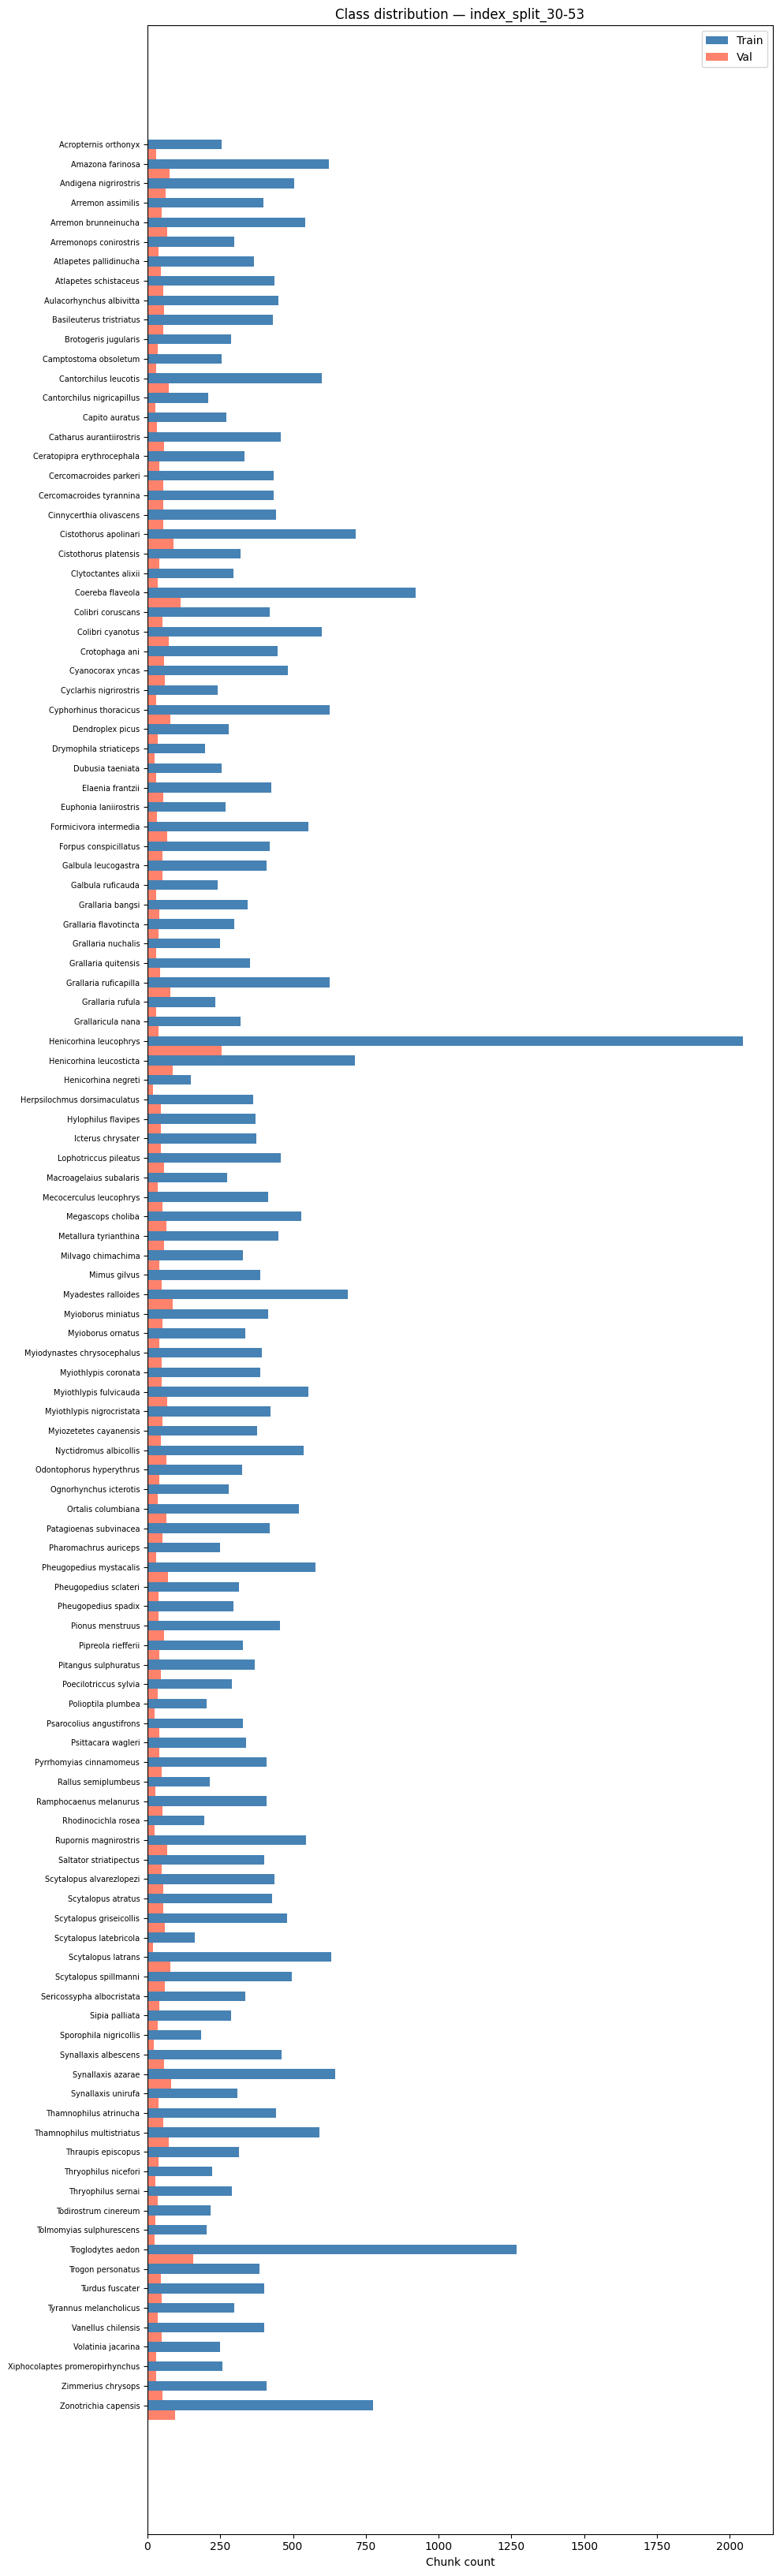

Train range  : [148, 2046]  mean=415.1
Val range    : [18,   255]    mean=51.3


In [19]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# ── Load and validate dataset index ───────────────────────────────────────
df_index = pd.read_parquet(DATASET_INDEX_PATH)
required_columns = {"tensor_path", "label", "split", "scientific_name"}
missing_columns = required_columns - set(df_index.columns)
if missing_columns:
    raise ValueError(f"dataset_index.parquet is missing required columns: {sorted(missing_columns)}")

if "common_name" not in df_index.columns:
    df_index["common_name"] = ""

df_index = df_index.copy()
df_index["split"] = df_index["split"].astype(str).str.lower()
df_index["label"] = df_index["label"].astype(int)

# Build label map from the preprocessing labels. Labels must be contiguous
# because sparse_categorical_crossentropy expects class ids in [0, N_CLASSES).
label_table = (
    df_index[["label", "scientific_name", "common_name"]]
    .drop_duplicates(subset=["label"])
    .sort_values("label")
)
expected_labels = list(range(len(label_table)))
actual_labels = label_table["label"].astype(int).tolist()
if actual_labels != expected_labels:
    raise ValueError(
        "Labels in dataset_index.parquet must be contiguous starting at 0. "
        f"Expected {expected_labels[:5]}... got {actual_labels[:5]}..."
    )

label_map = {
    int(row.label): row.scientific_name
    for row in label_table.itertuples(index=False)
}
N_CLASSES = len(label_map)
species_names = [label_map[i] for i in range(N_CLASSES)]

train_df = df_index[df_index["split"].eq("train")].copy().reset_index(drop=True)
val_df = df_index[df_index["split"].eq("val")].copy().reset_index(drop=True)
if train_df.empty or val_df.empty:
    raise ValueError(
        f"Expected non-empty train and val splits, got train={len(train_df):,}, val={len(val_df):,}"
    )

print(f"Rows in index : {len(df_index):,}")
print(f"Classes       : {N_CLASSES}")
print(f"Train rows    : {len(train_df):,}")
print(f"Val rows      : {len(val_df):,}")


def available_ram_gb():
    """Return available system RAM in GB on Linux runtimes, or None."""
    try:
        with open("/proc/meminfo", "r", encoding="utf-8") as fh:
            for line in fh:
                if line.startswith("MemAvailable:"):
                    return int(line.split()[1]) / 1_048_576
    except OSError:
        return None
    return None


def cache_tensor_files(df_split, split_name):
    """Ensure every tensor for a split is available locally and return an updated DataFrame."""
    df_split = df_split.copy()
    local_paths = []
    downloaded = 0
    reused = 0
    missing = []

    for tensor_path_value in tqdm(
        df_split["tensor_path"].astype(str).tolist(),
        desc=f"Caching {split_name} tensors",
        unit="tensor",
    ):
        source_path = Path(tensor_path_value)
        if source_path.exists():
            local_paths.append(str(source_path))
            reused += 1
            continue

        target_path = local_tensor_path(tensor_path_value)
        if not target_path.exists():
            key = tensor_s3_key(tensor_path_value)
            try:
                s3_client.download_file(s3_feature_bucket, key, str(target_path))
                downloaded += 1
            except Exception as exc:
                missing.append((tensor_path_value, key, str(exc)))
                continue
        else:
            reused += 1
        local_paths.append(str(target_path))

    if missing:
        examples = "\n".join(
            f"  tensor_path={path}  key=s3://{s3_feature_bucket}/{key}  error={err}"
            for path, key, err in missing[:5]
        )
        raise RuntimeError(
            f"Failed to cache {len(missing):,} {split_name} tensor(s). First failures:\n{examples}"
        )

    df_split["local_tensor_path"] = local_paths
    print(f"{split_name:<5} tensors cached: downloaded={downloaded:,}, reused={reused:,}")
    return df_split


train_df = cache_tensor_files(train_df, "train")
val_df = cache_tensor_files(val_df, "val")

y_train = train_df["label"].to_numpy(dtype=np.int32)
y_val = val_df["label"].to_numpy(dtype=np.int32)

# ── Tensor shape validation ───────────────────────────────────────────────
sample_tensor = np.load(train_df["local_tensor_path"].iloc[0], mmap_mode="r")
if sample_tensor.ndim != 3:
    raise ValueError(f"Expected channels-last 3D tensor, got shape={sample_tensor.shape}")
INPUT_HEIGHT, INPUT_WIDTH, INPUT_CHANNELS = map(int, sample_tensor.shape)
INPUT_SHAPE = (INPUT_HEIGHT, INPUT_WIDTH, INPUT_CHANNELS)
TENSOR_DTYPE = sample_tensor.dtype
if INPUT_SHAPE != (128, 431, 1):
    raise ValueError(f"Expected tensor shape (128, 431, 1), got {INPUT_SHAPE}")

val_sample = np.load(val_df["local_tensor_path"].iloc[0], mmap_mode="r")
if tuple(val_sample.shape) != INPUT_SHAPE:
    raise ValueError(f"Train/val tensor shape mismatch: train={INPUT_SHAPE}, val={val_sample.shape}")

ram_gb = available_ram_gb()
if ram_gb is not None:
    tensor_files_gb = sum(
        os.path.getsize(path)
        for path in pd.concat([train_df["local_tensor_path"], val_df["local_tensor_path"]]).unique()
    ) / 1_073_741_824
    print(f"Available RAM : {ram_gb:.2f} GB")
    print(f"Tensor files  : {tensor_files_gb:.2f} GB on disk (streamed from .npy files)")

print(f"Input shape   : {INPUT_SHAPE}  dtype={TENSOR_DTYPE}")
print(f"Val %         : {100 * len(y_val) / (len(y_train) + len(y_val)):.1f}%")

# ── Class distribution bar chart ──────────────────────────────────────────
train_counts = np.bincount(y_train, minlength=N_CLASSES)
val_counts = np.bincount(y_val, minlength=N_CLASSES)

fig_h = max(6, N_CLASSES * 0.28)
fig, ax = plt.subplots(figsize=(10, fig_h))
y_pos = np.arange(N_CLASSES)
ax.barh(y_pos, train_counts, height=0.5, label="Train", color="steelblue")
ax.barh(y_pos + 0.5, val_counts, height=0.5, label="Val", color="tomato", alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels([s.replace("_", " ") for s in species_names], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("Chunk count")
ax.set_title(f"Class distribution — {RUN_NAME}")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Train range  : [{train_counts.min()}, {train_counts.max()}]  mean={train_counts.mean():.1f}")
print(f"Val range    : [{val_counts.min()},   {val_counts.max()}]    mean={val_counts.mean():.1f}")

## Step 5 — Build `tf.data` Pipelines

Constructs memory-bounded `tf.data` input pipelines from cached `.npy` tensors referenced by `dataset_index.parquet`:
- **Train**: tensor paths → `.npy` loader → shuffle → augment → batch → prefetch
- **Val**: tensor paths → `.npy` loader → batch → prefetch

Preprocessing already writes each tensor as `(128, 431, 1)` in channels-last format.
Augmentation is applied only to training data.
Validation is intentionally not cached in memory so large splits do not duplicate tensors in RAM.

In [20]:
import numpy as np
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE
PREFETCH_BUFFER = 1


def _load_npy_tensor(path, label):
    """Load one cached .npy tensor for tf.py_function."""
    tensor_path = path.numpy().decode("utf-8")
    tensor = np.load(tensor_path).astype(np.float32)
    label = np.asarray(label.numpy(), dtype=np.int32)
    return tensor, label


def load_tensor(path, label):
    spec, label = tf.py_function(
        _load_npy_tensor,
        inp=[path, label],
        Tout=[tf.float32, tf.int32],
    )
    spec.set_shape(INPUT_SHAPE)
    label.set_shape(())
    return spec, label


def augment(spec, label):
    spec = tf.image.random_flip_left_right(spec)
    spec = tf.image.random_brightness(spec, max_delta=0.05)
    spec = tf.image.random_contrast(spec, lower=0.9, upper=1.1)
    spec = tf.clip_by_value(spec, -5.0, 5.0)
    return spec, label


def make_split_dataset(df_split, training):
    paths = df_split["local_tensor_path"].astype(str).to_numpy()
    labels = df_split["label"].astype(np.int32).to_numpy()

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(
            buffer_size=min(SHUFFLE_BUFFER, len(df_split)),
            reshuffle_each_iteration=True,
        )
    ds = ds.map(load_tensor, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE, drop_remainder=training).prefetch(PREFETCH_BUFFER)


train_ds = make_split_dataset(train_df, training=True)
val_ds = make_split_dataset(val_df, training=False)

print("tf.data pipelines configured from cached .npy tensors.")
print(f"  Input shape     : {INPUT_SHAPE}")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Shuffle buffer  : {min(SHUFFLE_BUFFER, len(train_df))}")
print(f"  Prefetch buffer : {PREFETCH_BUFFER}")

tf.data pipelines configured from cached .npy tensors.
  Input shape     : (128, 431, 1)
  Batch size      : 24
  Shuffle buffer  : 10000
  Prefetch buffer : 1


## Step 6 — Build Model

Architecture:
```
Input (128, 431, 1)
  → Concatenate: repeat grayscale channel × 3  →  (128, 431, 3)
  → ResNet50V2 backbone (ImageNet weights, top removed)
  → GlobalAveragePooling2D
  → BatchNormalization
  → Dense(256, relu)
  → Dropout(0.3)
  → Dense(N_CLASSES, softmax)
```

The concatenation layer converts the single-channel z-scored log-Mel tensor to 3 channels so that pretrained ImageNet weights can be applied directly.

In [21]:
import tensorflow as tf


def build_model(n_classes, input_height, input_width, input_channels, dropout_rate, dense_units):
    inputs = tf.keras.Input(
        shape=(input_height, input_width, input_channels),
        name="spectrogram",
    )

    # ResNet50V2 expects three channels. Concatenate instead of Lambda to avoid
    # serialization issues on load.
    if input_channels == 1:
        x = tf.keras.layers.Concatenate(axis=-1, name="to_rgb")([inputs, inputs, inputs])
    elif input_channels == 3:
        x = inputs
    else:
        raise ValueError(f"Expected 1 or 3 input channels, got {input_channels}")

    # Pretrained backbone (weights frozen initially)
    base_model = tf.keras.applications.ResNet50V2(
        include_top=False,
        weights="imagenet",
        input_shape=(input_height, input_width, 3),
    )
    base_model.trainable = False

    x = base_model(x, training=False)

    # Classification head
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Dense(dense_units, activation="relu", name="head_dense")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_dropout")(x)
    outputs = tf.keras.layers.Dense(n_classes, activation="softmax", name="predictions")(x)

    model = tf.keras.Model(inputs, outputs, name="BirdSongClassifier")
    return model, base_model


model, base_model = build_model(
    n_classes=N_CLASSES,
    input_height=INPUT_HEIGHT,
    input_width=INPUT_WIDTH,
    input_channels=INPUT_CHANNELS,
    dropout_rate=DROPOUT_RATE,
    dense_units=DENSE_UNITS,
)

model.summary(line_length=90)
print(f"\nInput shape          : {INPUT_SHAPE}")
print(f"Base model trainable : {base_model.trainable}")
print(f"Total parameters     : {model.count_params():,}")

Model: "BirdSongClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ spectrogram (InputLayer) │ (None, 128, 431, 1)  │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ to_rgb (Concatenate)     │ (None, 128, 431, 3)  │            0 │ spectrogram[0][0],    │
│                          │                      │              │ spectrogram[0][0],    │
│                          │                      │              │ spectrogram[0][0]     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ resnet50v2 (Functional)  │ (None, 4, 14, 2048)  │   23,564,800 │ to_rgb[0][0]          │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ gap                      │ (None, 2048)         │            0 │ resnet50v2[0][0]      │
│ (GlobalAveragePooling2D) │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ head_bn                  │ (None, 2048)         │        8,192 │ gap[0][0]             │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ head_dense (Dense)       │ (None, 256)          │      524,544 │ head_bn[0][0]         │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ head_dropout (Dropout)   │ (None, 256)          │            0 │ head_dense[0][0]      │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ predictions (Dense)      │ (None, 117)          │       30,069 │ head_dropout[0][0]    │
└──────────────────────────┴──────────────────────┴──────────────┴───────────────────────┘

 Total params: 24,127,605 (92.04 MB)

 Trainable params: 558,709 (2.13 MB)

 Non-trainable params: 23,568,896 (89.91 MB)


Input shape          : (128, 431, 1)
Base model trainable : False
Total parameters     : 24,127,605


## Step 7 — Phase 1: Train Classification Head

The ResNet50V2 base is **frozen**. Only the new classification head layers are trained.

This lets the head adapt to the spectrogram feature space before any fine-tuning disturbs the pretrained weights.

In [22]:
import tensorflow as tf

# ── Compile ───────────────────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_PHASE1),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_accuracy"),
    ],
)

# ── Callbacks ─────────────────────────────────────────────────────────────
callbacks_phase1 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINT_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=REDUCE_LR_FACTOR,
        patience=REDUCE_LR_PATIENCE,
        min_lr=1e-7,
        verbose=1,
    ),
]

print("Phase 1 — training classification head ...")
history_phase1 = model.fit(
    train_ds,
    epochs=EPOCHS_PHASE1,
    validation_data=val_ds,
    callbacks=callbacks_phase1,
    verbose=1,
)

val_acc_p1 = max(history_phase1.history["val_accuracy"])
print(f"\nPhase 1 complete. Best val accuracy: {val_acc_p1:.4f}")

Phase 1 — training classification head ...
Epoch 1/30


I0000 00:00:1781122990.096463  145984 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21904774__.174


2023/2023 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.2680 - loss: 3.4033 - top5_accuracy: 0.4857
Epoch 1: val_accuracy improved from None to 0.32467, saving model to /tmp/bird_models/index_split_30-53_best.weights.h5
2023/2023 ━━━━━━━━━━━━━━━━━━━━ 163s 77ms/step - accuracy: 0.3042 - loss: 3.1253 - top5_accuracy: 0.5377 - val_accuracy: 0.3247 - val_loss: 3.1097 - val_top5_accuracy: 0.5437 - learning_rate: 0.0010
Epoch 2/30
2023/2023 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4130 - loss: 2.5133 - top5_accuracy: 0.6601
Epoch 2: val_accuracy improved from 0.32467 to 0.37883, saving model to /tmp/bird_models/index_split_30-53_best.weights.h5
2023/2023 ━━━━━━━━━━━━━━━━━━━━ 152s 75ms/step - accuracy: 0.4132 - loss: 2.4863 - top5_accuracy: 0.6627 - val_accuracy: 0.3788 - val_loss: 2.8151 - val_top5_accuracy: 0.6025 - learning_rate: 0.0010
Epoch 3/30
2023/2023 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4657 - loss: 2.2335 - top5_accuracy: 0.7105
Epoch 3: val_accuracy improved fr

KeyboardInterrupt: 

## Step 8 — Phase 2: Fine-Tune Top Layers

Unfreeze the **last `UNFREEZE_FROM` layers** of the ResNet50V2 base and continue training with a learning rate 10× lower than Phase 1 to preserve the pretrained representations.

In [15]:
import tensorflow as tf

# ── Unfreeze top layers of base ───────────────────────────────────────────
base_model.trainable = True
for layer in base_model.layers[:UNFREEZE_FROM]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Base layers now trainable : {trainable_count} / {len(base_model.layers)}")

# ── Recompile at lower LR ─────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_PHASE2),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_accuracy"),
    ],
)

callbacks_phase2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINT_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=REDUCE_LR_FACTOR,
        patience=REDUCE_LR_PATIENCE,
        min_lr=1e-8,
        verbose=1,
    ),
]

print("Phase 2 — fine-tuning top layers ...")
history_phase2 = model.fit(
    train_ds,
    initial_epoch=len(history_phase1.history["loss"]),
    epochs=len(history_phase1.history["loss"]) + EPOCHS_PHASE2,
    validation_data=val_ds,
    callbacks=callbacks_phase2,
    verbose=1,
)

val_acc_p2 = max(history_phase2.history["val_accuracy"])
print(f"\nPhase 2 complete. Best val accuracy: {val_acc_p2:.4f}")

Base layers now trainable : 50 / 190
Phase 2 — fine-tuning top layers ...
Epoch 31/80


I0000 00:00:1781111483.671847  145985 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10448783__.200


2023/2023 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.4500 - loss: 2.5392 - top5_accuracy: 0.6937
Epoch 31: val_accuracy improved from None to 0.58633, saving model to /tmp/bird_models/index_split_best.weights.h5
2023/2023 ━━━━━━━━━━━━━━━━━━━━ 249s 112ms/step - accuracy: 0.5008 - loss: 2.1437 - top5_accuracy: 0.7416 - val_accuracy: 0.5863 - val_loss: 1.8051 - val_top5_accuracy: 0.7997 - learning_rate: 1.0000e-04
Epoch 32/80
2023/2023 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6183 - loss: 1.5688 - top5_accuracy: 0.8242
Epoch 32: val_accuracy improved from 0.58633 to 0.64950, saving model to /tmp/bird_models/index_split_best.weights.h5
2023/2023 ━━━━━━━━━━━━━━━━━━━━ 225s 111ms/step - accuracy: 0.6255 - loss: 1.5170 - top5_accuracy: 0.8307 - val_accuracy: 0.6495 - val_loss: 1.5257 - val_top5_accuracy: 0.8320 - learning_rate: 1.0000e-04
Epoch 33/80
2023/2023 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6843 - loss: 1.2645 - top5_accuracy: 0.8677
Epoch 33: val_accuracy impro

## Step 9 — Evaluation & Diagnostics

Four diagnostic outputs:
1. **Learning curves** — train/val accuracy and loss across both phases
2. **Confusion matrix** — predicted vs. true species (normalised by row)
3. **Per-class accuracy** — horizontal bar chart, sorted ascending
4. **Summary metrics** — top-1 accuracy, top-5 accuracy, macro F1, weighted F1

Saved plot locally: /tmp/bird_models/plots/index_split_learning_curves.png
Uploaded plot     : s3://birdsongs-dev-sagemaker-training-760964999831/outputs/index_split_learning_curves.png


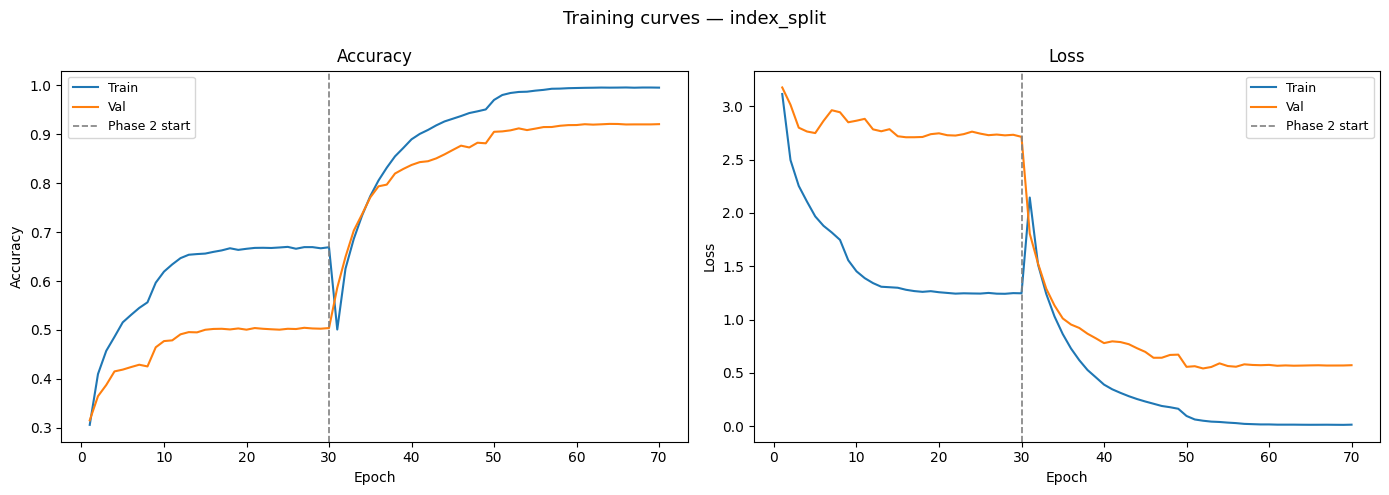

Running inference on validation set ...
Saved plot locally: /tmp/bird_models/plots/index_split_confusion_matrix.png
Uploaded plot     : s3://birdsongs-dev-sagemaker-training-760964999831/outputs/index_split_confusion_matrix.png


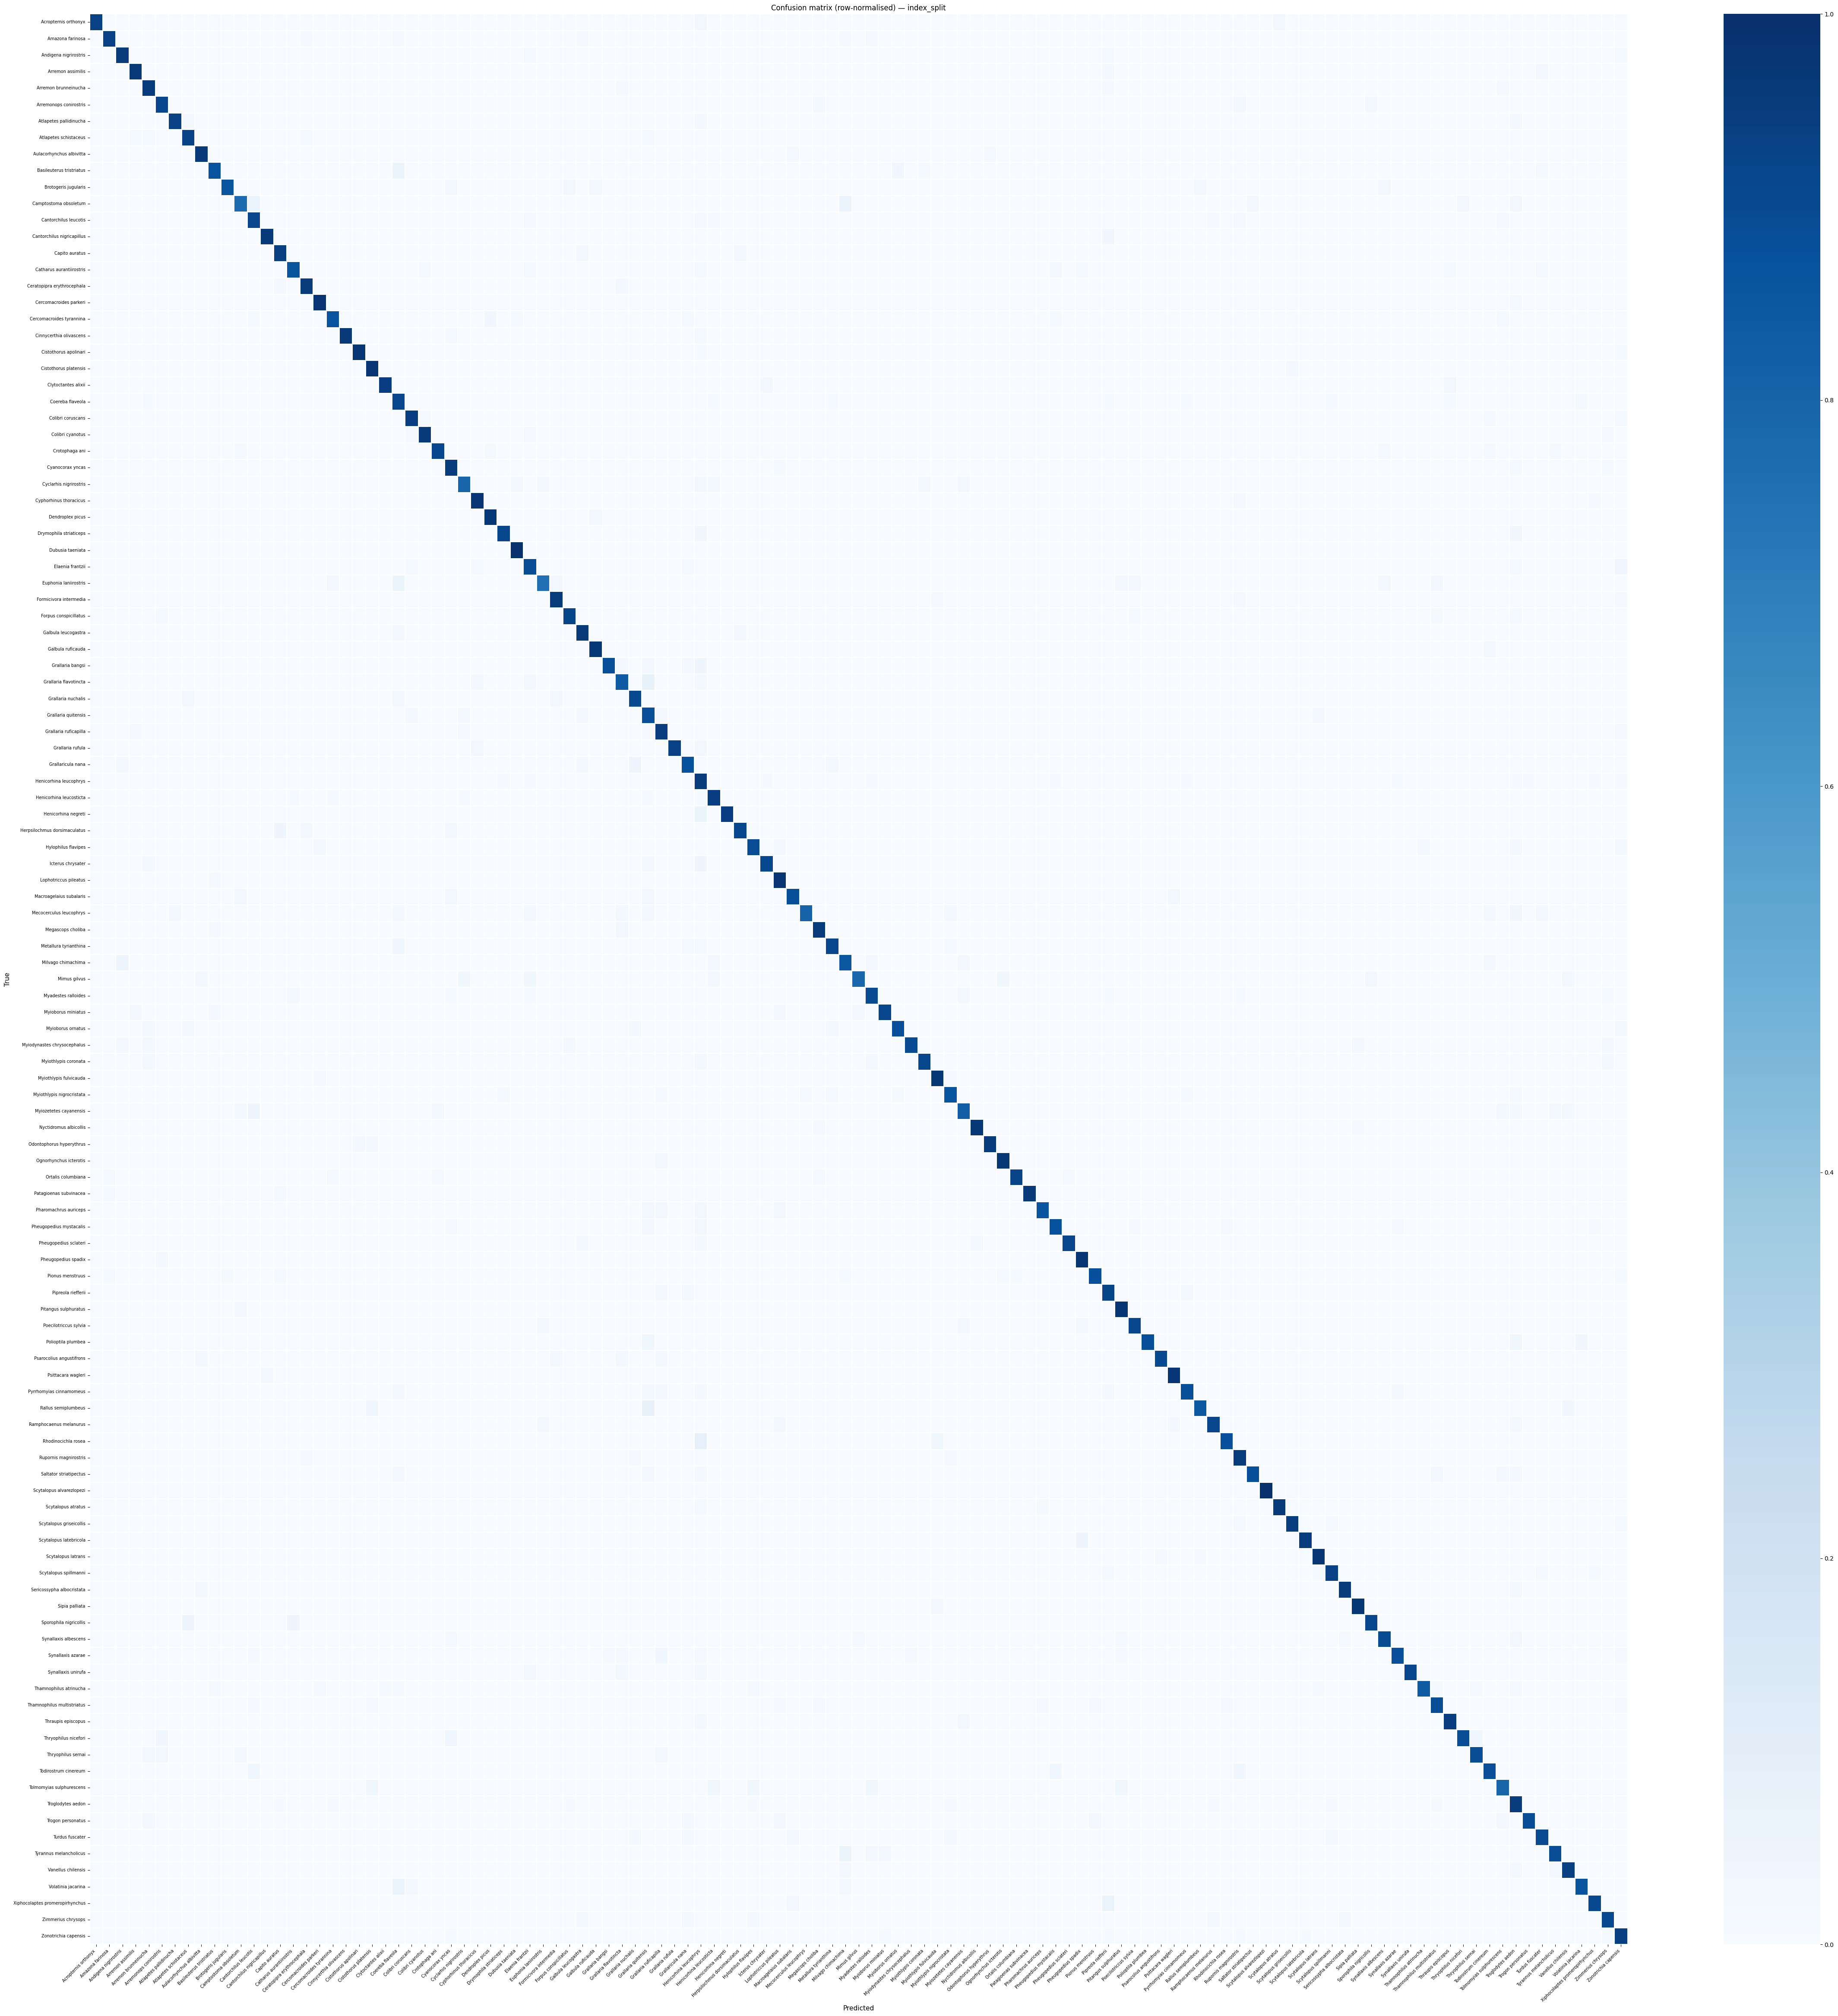

Saved plot locally: /tmp/bird_models/plots/index_split_per_class_accuracy.png
Uploaded plot     : s3://birdsongs-dev-sagemaker-training-760964999831/outputs/index_split_per_class_accuracy.png


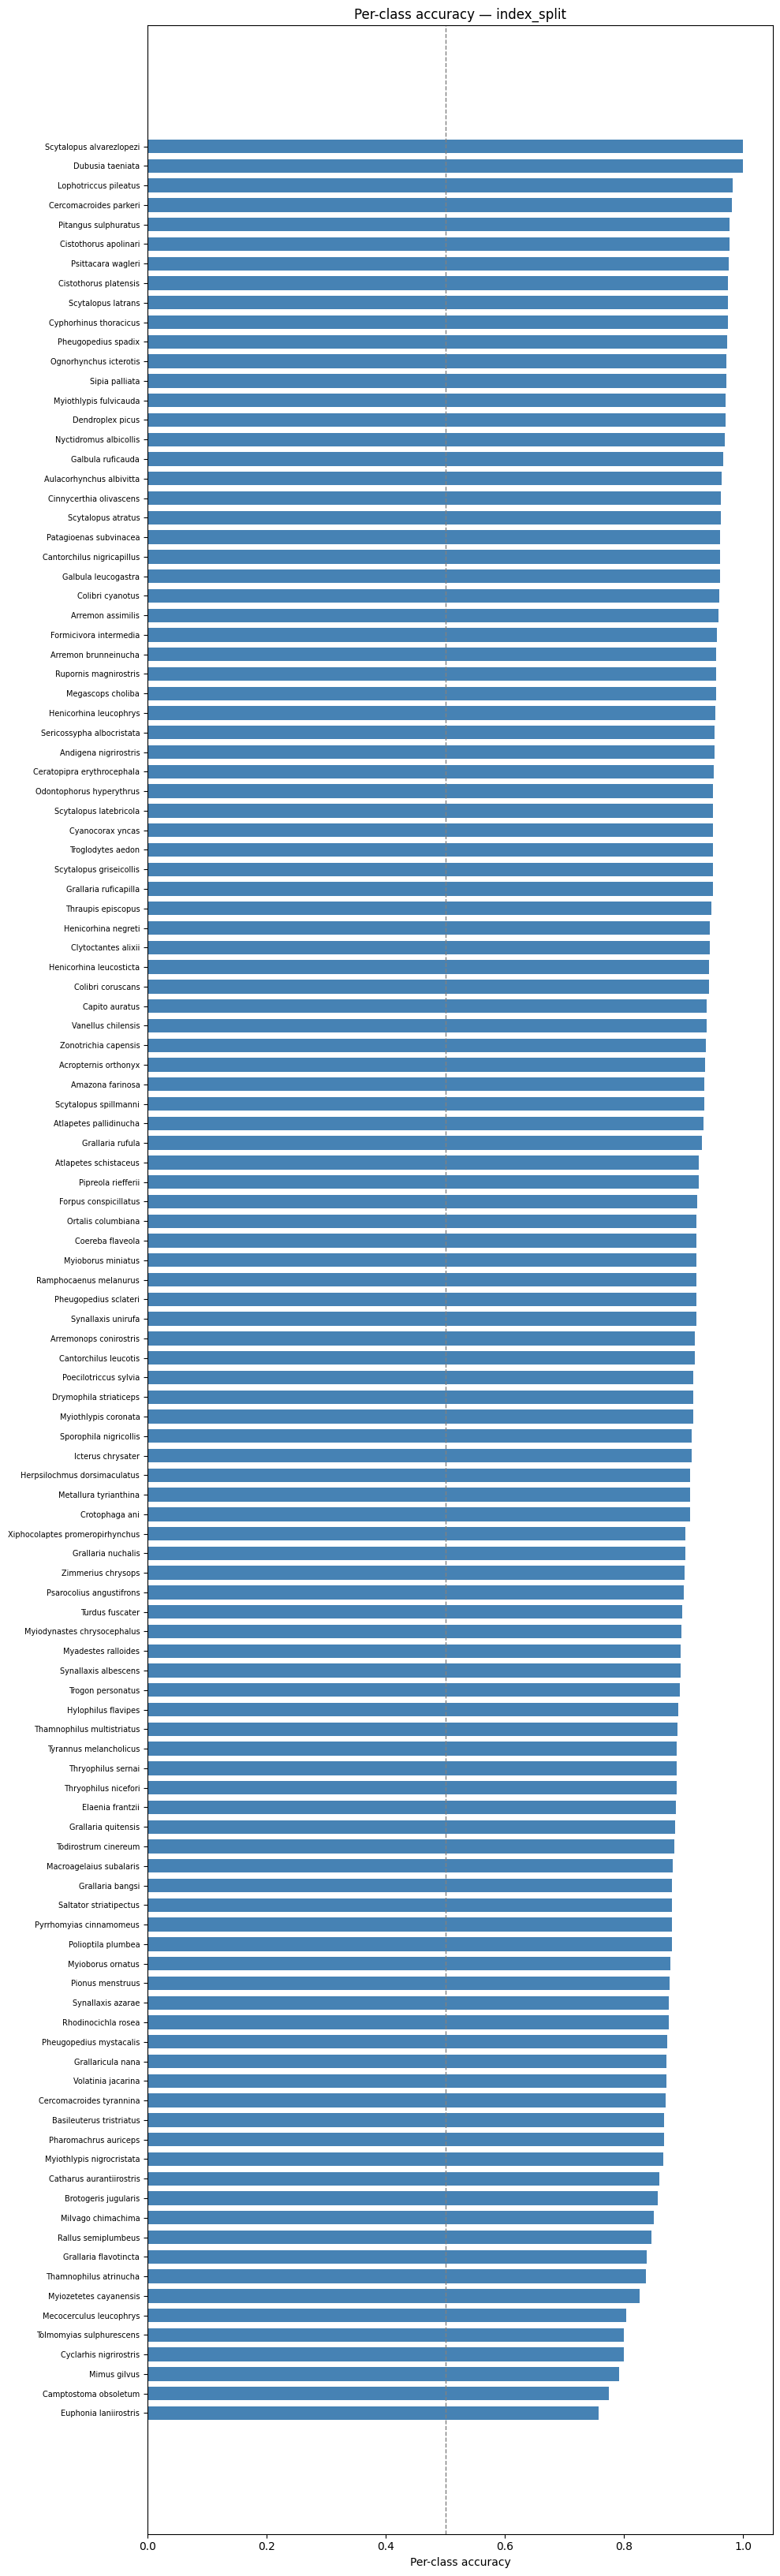


  Top-1 accuracy : 0.9213
  Top-5 accuracy : 0.9693
  Macro F1       : 0.9186
  Weighted F1    : 0.9216

Worst 5 species: ['Euphonia laniirostris', 'Camptostoma obsoletum', 'Mimus gilvus', 'Cyclarhis nigrirostris', 'Tolmomyias sulphurescens']
Best  5 species: ['Pitangus sulphuratus', 'Cercomacroides parkeri', 'Lophotriccus pileatus', 'Dubusia taeniata', 'Scytalopus alvarezlopezi']
Saved plot locally: /tmp/bird_models/plots/index_split_auc_roc_pr.png
Uploaded plot     : s3://birdsongs-dev-sagemaker-training-760964999831/outputs/index_split_auc_roc_pr.png


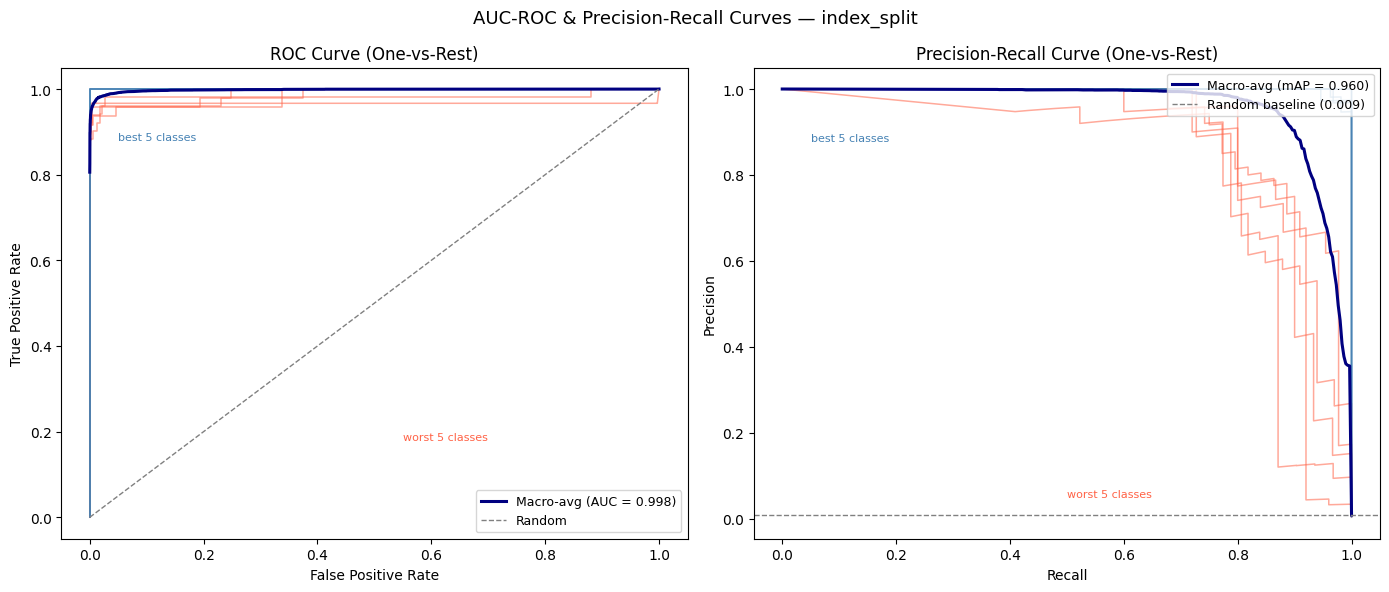

  Macro AUC-ROC      : 0.9978
  Mean Avg Precision : 0.9595


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, f1_score, top_k_accuracy_score
)

PLOT_OUTPUT_DIR = MODELS_DIR / "plots"
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def save_plot_to_output(fig, filename, dpi=120):
    """Save a diagnostic plot locally and upload it to the configured S3 output prefix."""
    local_path = PLOT_OUTPUT_DIR / filename
    fig.savefig(str(local_path), dpi=dpi)

    s3_key = f"{s3_output_prefix}{filename}".lstrip("/")
    s3_client.upload_file(str(local_path), s3_output_bucket, s3_key)
    print(f"Saved plot locally: {local_path}")
    print(f"Uploaded plot     : s3://{s3_output_bucket}/{s3_key}")
    return local_path


# ── 1. Learning curves (phases 1 + 2 combined) ───────────────────────────
acc      = history_phase1.history["accuracy"]     + history_phase2.history["accuracy"]
val_acc  = history_phase1.history["val_accuracy"] + history_phase2.history["val_accuracy"]
loss     = history_phase1.history["loss"]         + history_phase2.history["loss"]
val_loss = history_phase1.history["val_loss"]     + history_phase2.history["val_loss"]
phase_boundary = len(history_phase1.history["loss"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Training curves — {RUN_NAME}", fontsize=13)

for ax, train_vals, val_vals, ylabel in zip(
    axes,
    [acc, loss],
    [val_acc, val_loss],
    ["Accuracy", "Loss"],
):
    epochs = range(1, len(train_vals) + 1)
    ax.plot(epochs, train_vals, label="Train")
    ax.plot(epochs, val_vals,   label="Val")
    ax.axvline(phase_boundary, color="gray", linestyle="--", linewidth=1.2, label="Phase 2 start")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=9)

plt.tight_layout()
save_plot_to_output(fig, f"{RUN_NAME}_learning_curves.png")
plt.show()

# ── 2. Predictions on val set ─────────────────────────────────────────────
print("Running inference on validation set ...")
y_prob = model.predict(val_ds, verbose=0)   # (M, N_CLASSES)
y_pred = np.argmax(y_prob, axis=1)

# ── 3. Confusion matrix ───────────────────────────────────────────────────
cm     = confusion_matrix(y_val, y_pred, normalize="true")
labels = [s.replace("_", " ") for s in species_names]
fig_sz = max(12, N_CLASSES * 0.4)

fig, ax = plt.subplots(figsize=(fig_sz, fig_sz))
sns.heatmap(cm, annot=N_CLASSES <= 30, fmt=".2f",
            xticklabels=labels, yticklabels=labels,
            cmap="Blues", linewidths=0.3, ax=ax)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True", fontsize=11)
ax.set_title(f"Confusion matrix (row-normalised) — {RUN_NAME}", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
save_plot_to_output(fig, f"{RUN_NAME}_confusion_matrix.png")
plt.show()

# ── 4. Per-class accuracy bar chart ──────────────────────────────────────
per_class_acc = cm.diagonal()
sorted_idx    = np.argsort(per_class_acc)

fig, ax = plt.subplots(figsize=(10, max(6, N_CLASSES * 0.28)))
colors  = ["tomato" if v < 0.5 else "steelblue" for v in per_class_acc[sorted_idx]]
ax.barh(range(N_CLASSES), per_class_acc[sorted_idx], color=colors, height=0.7)
ax.set_yticks(range(N_CLASSES))
ax.set_yticklabels([labels[i] for i in sorted_idx], fontsize=7)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1.0)
ax.set_xlabel("Per-class accuracy")
ax.set_title(f"Per-class accuracy — {RUN_NAME}")
plt.tight_layout()
save_plot_to_output(fig, f"{RUN_NAME}_per_class_accuracy.png")
plt.show()

# ── 5. Summary metrics ────────────────────────────────────────────────────
top1_acc    = np.mean(y_pred == y_val)
top5_acc    = top_k_accuracy_score(y_val, y_prob, k=5)
macro_f1    = f1_score(y_val, y_pred, average="macro",    zero_division=0)
weighted_f1 = f1_score(y_val, y_pred, average="weighted", zero_division=0)

print("\n" + "=" * 40)
print(f"  Top-1 accuracy : {top1_acc:.4f}")
print(f"  Top-5 accuracy : {top5_acc:.4f}")
print(f"  Macro F1       : {macro_f1:.4f}")
print(f"  Weighted F1    : {weighted_f1:.4f}")
print("=" * 40)

worst5 = [labels[i] for i in sorted_idx[:5]]
best5  = [labels[i] for i in sorted_idx[-5:]]
print(f"\nWorst 5 species: {worst5}")
print(f"Best  5 species: {best5}")

# ── 6. AUC-ROC and Precision-Recall curves ───────────────────────────────
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
)

y_val_bin = label_binarize(y_val, classes=list(range(N_CLASSES)))

fpr_all, tpr_all, roc_auc_all = {}, {}, {}
prec_all, rec_all, ap_all     = {}, {}, {}

for i in range(N_CLASSES):
    fpr_all[i], tpr_all[i], _ = roc_curve(y_val_bin[:, i], y_prob[:, i])
    roc_auc_all[i]             = auc(fpr_all[i], tpr_all[i])
    prec_all[i], rec_all[i], _ = precision_recall_curve(y_val_bin[:, i], y_prob[:, i])
    ap_all[i]                  = average_precision_score(y_val_bin[:, i], y_prob[:, i])

# Macro-average ROC
all_fpr  = np.unique(np.concatenate([fpr_all[i] for i in range(N_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(N_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr_all[i], tpr_all[i])
mean_tpr /= N_CLASSES
macro_roc_auc = auc(all_fpr, mean_tpr)

# Macro mean-average precision
mean_ap = float(np.mean([ap_all[i] for i in range(N_CLASSES)]))

# Indices of worst / best 5 classes by AUC and AP
roc_auc_vals = np.array([roc_auc_all[i] for i in range(N_CLASSES)])
ap_vals      = np.array([ap_all[i]      for i in range(N_CLASSES)])
worst5_roc   = np.argsort(roc_auc_vals)[:5]
best5_roc    = np.argsort(roc_auc_vals)[-5:]
worst5_ap    = np.argsort(ap_vals)[:5]
best5_ap     = np.argsort(ap_vals)[-5:]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"AUC-ROC & Precision-Recall Curves — {RUN_NAME}", fontsize=13)

# ── ROC subplot ───────────────────────────────────────────────────────────
ax = axes[0]
for i in worst5_roc:
    ax.plot(fpr_all[i], tpr_all[i], color="tomato",    alpha=0.55, lw=1.1)
for i in best5_roc:
    ax.plot(fpr_all[i], tpr_all[i], color="steelblue", alpha=0.55, lw=1.1)
ax.plot(all_fpr, mean_tpr, color="navy", lw=2.2,
        label=f"Macro-avg (AUC = {macro_roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve (One-vs-Rest)")
ax.legend(fontsize=9, loc="lower right")
ax.annotate("worst 5 classes", xy=(0.55, 0.18), color="tomato",    fontsize=8)
ax.annotate("best 5 classes",  xy=(0.05, 0.88), color="steelblue", fontsize=8)

# ── PR subplot ────────────────────────────────────────────────────────────
ax = axes[1]
for i in worst5_ap:
    ax.plot(rec_all[i], prec_all[i], color="tomato",    alpha=0.55, lw=1.1)
for i in best5_ap:
    ax.plot(rec_all[i], prec_all[i], color="steelblue", alpha=0.55, lw=1.1)

# Interpolated macro PR (rec_all[i] is decreasing → reverse for np.interp)
all_rec_grid     = np.linspace(0, 1, 300)
mean_prec_interp = np.zeros(300)
for i in range(N_CLASSES):
    mean_prec_interp += np.interp(all_rec_grid,
                                  rec_all[i][::-1],
                                  prec_all[i][::-1])
mean_prec_interp /= N_CLASSES

ax.plot(all_rec_grid, mean_prec_interp, color="navy", lw=2.2,
        label=f"Macro-avg (mAP = {mean_ap:.3f})")
ax.axhline(1.0 / N_CLASSES, color="gray", linestyle="--", lw=1,
           label=f"Random baseline ({1.0 / N_CLASSES:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve (One-vs-Rest)")
ax.legend(fontsize=9, loc="upper right")
ax.annotate("worst 5 classes", xy=(0.5,  0.05), color="tomato",    fontsize=8)
ax.annotate("best 5 classes",  xy=(0.05, 0.88), color="steelblue", fontsize=8)

plt.tight_layout()
save_plot_to_output(fig, f"{RUN_NAME}_auc_roc_pr.png")
plt.show()

print(f"  Macro AUC-ROC      : {macro_roc_auc:.4f}")
print(f"  Mean Avg Precision : {mean_ap:.4f}")

## Step 10 — Save Model & Best Weights

Saves the trained model in Keras native format and exports the currently restored best weights as a separate `.weights.h5` artifact. Both files are uploaded to S3.

In [ ]:
BEST_WEIGHTS_PATH = MODELS_DIR / f"resnet50v2_{RUN_NAME}_best.weights.h5"

model.save(str(FINAL_MODEL_PATH))
model.save_weights(str(BEST_WEIGHTS_PATH))
print(f"Model saved locally       : {FINAL_MODEL_PATH}")
print(f"Best weights saved locally: {BEST_WEIGHTS_PATH}")

# ── Upload model and best weights to S3 ───────────────────────────────────
print(f"\nUploading model artifacts to S3...")
model_filename = FINAL_MODEL_PATH.name
weights_filename = BEST_WEIGHTS_PATH.name
s3_model_key   = f"{s3_output_prefix}{model_filename}".lstrip("/")
s3_weights_key = f"{s3_output_prefix}{weights_filename}".lstrip("/")

try:
    s3_client.upload_file(
        str(FINAL_MODEL_PATH),
        s3_output_bucket,
        s3_model_key,
    )
    s3_model_uri = f"s3://{s3_output_bucket}/{s3_model_key}"
    print(f"✓ Model uploaded: {s3_model_uri}")
except Exception as e:
    print(f"✗ Model upload failed: {e}")
    raise

try:
    s3_client.upload_file(
        str(BEST_WEIGHTS_PATH),
        s3_output_bucket,
        s3_weights_key,
    )
    s3_weights_uri = f"s3://{s3_output_bucket}/{s3_weights_key}"
    print(f"✓ Best weights uploaded: {s3_weights_uri}")
except Exception as e:
    print(f"✗ Best weights upload failed: {e}")
    raise

# ── Original training checkpoint also uploaded when present ───────────────
checkpoint_filename = CHECKPOINT_PATH.name
s3_checkpoint_key   = f"{s3_output_prefix}{checkpoint_filename}".lstrip("/")
if CHECKPOINT_PATH.exists() and CHECKPOINT_PATH != BEST_WEIGHTS_PATH:
    try:
        s3_client.upload_file(
            str(CHECKPOINT_PATH),
            s3_output_bucket,
            s3_checkpoint_key,
        )
        s3_checkpoint_uri = f"s3://{s3_output_bucket}/{s3_checkpoint_key}"
        print(f"✓ Training checkpoint uploaded: {s3_checkpoint_uri}")
    except Exception as e:
        print(f"⚠ Training checkpoint upload failed (non-critical): {e}")

print(f"\n✓ Training complete!")
print(f"  Model files:")
print(f"    Model local   : {FINAL_MODEL_PATH}")
print(f"    Model S3      : {s3_model_uri}")
print(f"    Weights local : {BEST_WEIGHTS_PATH}")
print(f"    Weights S3    : {s3_weights_uri}")

# ── To restore the model ──────────────────────────────────────────────────
print(f"\nTo restore the model from S3:")
print(f"  import boto3; import tensorflow as tf")
print(f"  s3 = boto3.client('s3')")
print(f"  s3.download_file('{s3_output_bucket}', '{s3_model_key}', 'model.keras')")
print(f"  model = tf.keras.models.load_model('model.keras')")
print(f"\nTo restore weights into the same architecture:")
print(f"  s3.download_file('{s3_output_bucket}', '{s3_weights_key}', 'best.weights.h5')")
print(f"  model.load_weights('best.weights.h5')")

## Step 11 — Inference Helper (SageMaker / S3 Compatible)

Given any raw audio file, creates the same normalized log-Mel tensors used for training and returns the **top-3 predicted species** with confidence scores.

Can load the trained model from local disk OR download from S3 via boto3.
The feature parameters match `pre_processing.ipynb` Block 6: `(128, 431, 1)` log-Mel tensors with per-Mel-bin z-score normalization from `norm_stats.parquet`.

> **Configuration:** Set `USE_S3_MODEL = True` to load the model from S3. Set `USE_S3_METADATA = True` if `dataset_index.parquet` and `norm_stats.parquet` are not already local.

In [ ]:
%pip install librosa soundfile scipy boto3 pandas pyarrow --quiet

import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import boto3
from pathlib import Path

# ── Configuration ─────────────────────────────────────────────────────────
# Model can be loaded from local path OR downloaded from S3.
DEFAULT_RUN_NAME = globals().get("RUN_NAME", "index_split")
MODEL_LOCAL_PATH = Path(globals().get("FINAL_MODEL_PATH", f"resnet50v2_{DEFAULT_RUN_NAME}.keras"))

# S3: Bucket and key for trained model.
S3_MODEL_BUCKET = globals().get("s3_output_bucket", "my-bucket")  # ← UPDATE if running standalone
S3_MODEL_KEY = f"{globals().get('s3_output_prefix', '')}{MODEL_LOCAL_PATH.name}".lstrip("/")
USE_S3_MODEL = False                                             # ← Set to True to download from S3

# ── Audio file for inference ──────────────────────────────────────────────
AUDIO_PATH = "bird_audio.mpeg"

# ── Metadata artifacts: dataset index and normalization stats ─────────────
def default_artifact_key(relative_key):
    if "artifact_key" in globals():
        return artifact_key(relative_key)
    return str(relative_key).lstrip("/")

DATASET_INDEX_LOCAL_PATH = Path(globals().get("DATASET_INDEX_PATH", "data/dataset_index.parquet"))
NORM_STATS_LOCAL_PATH    = Path(globals().get("NORM_STATS_PATH", "data/norm_stats.parquet"))
S3_METADATA_BUCKET       = globals().get("s3_feature_bucket", "my-bucket")       # ← UPDATE if running standalone
S3_DATASET_INDEX_KEY     = default_artifact_key(globals().get("DATASET_INDEX_KEY", "data/dataset_index.parquet"))
S3_NORM_STATS_KEY        = default_artifact_key(globals().get("NORM_STATS_KEY", "data/norm_stats.parquet"))
USE_S3_METADATA          = False                                                 # ← Set to True to download metadata

# ── Load metadata artifacts ────────────────────────────────────────────────
if USE_S3_METADATA:
    s3 = boto3.client("s3")
    local_index = Path("/tmp/dataset_index.parquet")
    local_stats = Path("/tmp/norm_stats.parquet")
    print(f"Downloading dataset index: s3://{S3_METADATA_BUCKET}/{S3_DATASET_INDEX_KEY}")
    s3.download_file(S3_METADATA_BUCKET, S3_DATASET_INDEX_KEY, str(local_index))
    print(f"Downloading norm stats   : s3://{S3_METADATA_BUCKET}/{S3_NORM_STATS_KEY}")
    s3.download_file(S3_METADATA_BUCKET, S3_NORM_STATS_KEY, str(local_stats))
    dataset_index_path = local_index
    norm_stats_path = local_stats
else:
    dataset_index_path = DATASET_INDEX_LOCAL_PATH
    norm_stats_path = NORM_STATS_LOCAL_PATH

if not dataset_index_path.exists():
    raise FileNotFoundError(f"Dataset index not found at {dataset_index_path}")
if not norm_stats_path.exists():
    raise FileNotFoundError(f"Normalization stats not found at {norm_stats_path}")

df_index = pd.read_parquet(dataset_index_path)
label_table = (
    df_index[["label", "scientific_name"]]
    .drop_duplicates(subset=["label"])
    .sort_values("label")
)
label_map = {
    int(row.label): row.scientific_name
    for row in label_table.itertuples(index=False)
}
print(f"✓ Labels loaded from dataset index ({len(label_map)} classes)")

norm_df = pd.read_parquet(norm_stats_path).sort_values("mel_bin")
norm_mean = norm_df["mean"].to_numpy(dtype=np.float32)
norm_std = np.maximum(norm_df["std"].to_numpy(dtype=np.float32), 1e-6)
print(f"✓ Normalization stats loaded ({len(norm_mean)} Mel bins)")

# ── Load Model ────────────────────────────────────────────────────────────
if USE_S3_MODEL:
    print(f"\nDownloading model from S3: s3://{S3_MODEL_BUCKET}/{S3_MODEL_KEY}")
    s3 = boto3.client("s3")
    local_model_path = Path("/tmp/resnet50v2_model.keras")
    s3.download_file(S3_MODEL_BUCKET, S3_MODEL_KEY, str(local_model_path))
    model_path = local_model_path
else:
    model_path = MODEL_LOCAL_PATH

if not model_path.exists():
    raise FileNotFoundError(f"Model not found at {model_path}")

print(f"Loading model from {model_path.name}...")
model = tf.keras.models.load_model(str(model_path))
print("✓ Model loaded successfully")

# ── Verify audio file ─────────────────────────────────────────────────────
if AUDIO_PATH is None or not Path(AUDIO_PATH).exists():
    raise ValueError(f"Please set AUDIO_PATH to an existing audio file. Current value: {AUDIO_PATH}")

# ── Feature constants matching pre_processing.ipynb Block 6 ───────────────
SR             = 22_050
CHUNK_LEN      = 3.0
MIN_CHUNK_LEN  = 1.0
CHUNK_SAMPLES  = int(SR * CHUNK_LEN)
STRIDE_SAMPLES = CHUNK_SAMPLES // 2
N_FFT          = 1024
HOP_LENGTH     = 256
N_MELS         = 128
F_MIN          = 300.0
F_MAX          = 10_000.0
TOP_DB         = 80
TARGET_FRAMES  = 431

if len(norm_mean) != N_MELS or len(norm_std) != N_MELS:
    raise ValueError(f"Expected {N_MELS} norm-stat rows, got mean={len(norm_mean)}, std={len(norm_std)}")

# ── Feature extraction ────────────────────────────────────────────────────
def audio_to_chunks(audio):
    if len(audio) < int(MIN_CHUNK_LEN * SR):
        return []
    if len(audio) < CHUNK_SAMPLES:
        padded = np.zeros(CHUNK_SAMPLES, dtype=np.float32)
        padded[:len(audio)] = audio
        return [padded]

    chunks = []
    for start in range(0, len(audio), STRIDE_SAMPLES):
        chunk = audio[start:start + CHUNK_SAMPLES]
        if len(chunk) == CHUNK_SAMPLES:
            chunks.append(chunk.astype(np.float32))
        elif len(chunk) >= int(MIN_CHUNK_LEN * SR):
            padded = np.zeros(CHUNK_SAMPLES, dtype=np.float32)
            padded[:len(chunk)] = chunk
            chunks.append(padded)
            break
        else:
            break
    return chunks


def chunk_to_tensor(chunk):
    mel = librosa.feature.melspectrogram(
        y=chunk,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=F_MIN,
        fmax=F_MAX,
        power=2.0,
    )
    log_mel = librosa.power_to_db(mel, ref=np.max, top_db=TOP_DB)

    if log_mel.shape[1] < TARGET_FRAMES:
        log_mel = np.pad(
            log_mel,
            ((0, 0), (0, TARGET_FRAMES - log_mel.shape[1])),
            mode="constant",
            constant_values=log_mel.min(),
        )
    else:
        log_mel = log_mel[:, :TARGET_FRAMES]

    tensor = (log_mel - norm_mean[:, None]) / norm_std[:, None]
    return tensor[:, :, np.newaxis].astype(np.float32)

# ── Inference ─────────────────────────────────────────────────────────────
audio, _ = librosa.load(AUDIO_PATH, sr=SR, mono=True)
source_label = Path(AUDIO_PATH).name
chunks = audio_to_chunks(audio)

if not chunks:
    raise ValueError("Audio is too short to extract any valid chunks.")

tensors_in = np.stack([chunk_to_tensor(c) for c in chunks], axis=0)

print(f"\nInference on {source_label}")
print(f"  Chunks      : {len(chunks)}")
print(f"  Tensor shape: {tensors_in.shape}")

# ── Predict ───────────────────────────────────────────────────────────────
chunk_probs = model.predict(tensors_in, verbose=0)  # (K, N_CLASSES)
avg_probs = chunk_probs.mean(axis=0)                # average across chunks

top3_indices = np.argsort(avg_probs)[::-1][:3]

print("\n── Top-3 predicted species ──────────────────")
for rank, idx in enumerate(top3_indices, 1):
    species = label_map[int(idx)].replace("_", " ")
    confidence = avg_probs[idx] * 100
    print(f"  {rank}. {species:<40}  {confidence:5.1f}%")
print("─────────────────────────────────────────────")